## channel segmentation analysis 

### Methodology (end-to-end)

**Goal:** for each acquisition channel, answer two separate questions — "how efficient is it?"
and "how much does it actually move the needle?" — and combine them into one view instead of
ranking channels on a single number.

**Data:** `data/StreamlineApp_ChannelSegmentation_Data.xlsx` ("Raw Data" sheet), one row per user:
`user_id`, `acquisition_channel`, `registration_date`, `activated` (0/1 flag). 7,390 rows, one row
per user (`user_id.nunique() == len(df)`, confirmed in the cells below), so no de-duplication is
needed before aggregating.

**Step 1 — per-channel activation rate.**
`df.groupby("acquisition_channel").agg(user_count=nunique, activated_count=sum)`, then
`activation_rate = activated_count / user_count`. This answers "of the users this channel
brought in, what fraction activated?" — a pure efficiency metric, independent of channel size.

**Step 2 — global baseline.**
`baseline_activation_rate = total_activated / total_users` across *all* channels combined
(34.11%). This is the single number every channel's `activation_rate` gets compared against — it
answers "is this channel better or worse than the blended average?"

**Step 3 — contribution metrics (`channel_summary`).** Efficiency alone doesn't capture volume: a
channel could have a great `activation_rate` but bring in so few users that it barely matters to
the business, or vice versa. Three more columns capture that:
- `contribution_pct` = this channel's share of *total activated users* (`activated_count / total_activated_count * 100`). Answers "what % of all activations came from here?"
- `user_share_pct` = this channel's share of *total users* (`user_count / total_users * 100`). This is what `contribution_pct` would equal if every channel converted at exactly the same rate — the size-proportional baseline.
- `contribution_index_pts` = `contribution_pct − user_share_pct`. Positive means the channel over-indexes (converts a bigger slice of total activations than its user volume alone predicts); negative means it under-delivers relative to its size. This column exists because an earlier version of this analysis benchmarked `contribution_pct` against a flat `mean()` across channels (`100 / n_channels`), which unfairly penalized small channels like Partner Referrals (90 users) that could never reach an equal per-channel share regardless of performance — see the markdown cell right before the chart for the full rationale.

**Step 4 — quadrant chart.** Plots every channel as one point: x = `activation_rate` (vs. the
`baseline_activation_rate` reference line), y = `contribution_index_pts` (vs. a `0` reference
line). Four quadrants:
- **top-right (green):** above-baseline efficiency *and* over-indexing on volume — the channels to double down on.
- **bottom-right (blue):** efficient, but under-delivering relative to size — room to scale up spend/volume.
- **top-left (orange):** inefficient, but still over-indexing on contribution — usually just a large channel; investigate before cutting.
- **bottom-left (red):** below-baseline efficiency *and* under-indexing — weakest quadrant, first candidates to fix or de-prioritize.

**Caveat:** this is a single-snapshot cross-sectional view (no time dimension, no cohort/spend
data), so it identifies *where* to look, not *why* a channel performs the way it does or whether
performance is trending up or down.


In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [66]:
df = pd.read_excel("data/StreamlineApp_ChannelSegmentation_Data.xlsx", sheet_name="Raw Data")
df["registration_date"] = pd.to_datetime(df["registration_date"])

print(df.shape)
df.head()

(7390, 4)


,user_id,acquisition_channel,registration_date,activated
0,U101191,Organic Search,2026-03-18,0
1,U107356,Partner Referrals,2026-04-30,0
2,U106261,Direct Traffic,2026-03-17,0
3,U107152,Email Marketing,2026-03-20,0
4,U103576,Paid Search,2026-03-22,0


In [67]:
df["user_id"].nunique()

7390

In [68]:
df.groupby("acquisition_channel").agg(
    user_count=("user_id", "nunique"),
    activated_count=("activated", "sum")
).assign(activation_rate=lambda x: (x["activated_count"] / x["user_count"]).round(4)
).sort_values("user_count", ascending=False).reset_index()

,acquisition_channel,user_count,activated_count,activation_rate
0,Organic Search,2200,833,0.3786
1,Paid Search,1800,554,0.3078
2,Social Media Ads,1500,383,0.2553
3,Direct Traffic,1200,435,0.3625
4,Email Marketing,600,261,0.4350
5,Partner Referrals,90,55,0.6111


In [69]:
## top and bottom channels 
# top 3 i would say in order are - organic , direct and then email 
# bottom 2 i would say  search and social media (in that order)
# partner referrals is great but it wont scale well as partners can only refer only so many people

In [70]:
total_users = df["user_id"].nunique()
total_activated = df["activated"].sum()
baseline_activation_rate = total_activated / total_users

print(f"Total users:           {total_users:,}")
print(f"Total activated:       {total_activated:,}")
print(f"Baseline activation rate: {baseline_activation_rate:.2%}")

Total users:           7,390
Total activated:       2,521
Baseline activation rate: 34.11%


In [71]:
channel_summary = df.groupby("acquisition_channel").agg(
    user_count=("user_id", "nunique"),
    activated_count=("activated", "sum")
).assign(
    activation_rate=lambda x: (x["activated_count"] / x["user_count"]).round(4),
    contribution_pct=lambda x: (x["activated_count"] / x["activated_count"].sum() * 100).round(2),
    # user_share_pct = what % of activations this channel would be "expected" to contribute
    # if every channel converted at the same (baseline) rate — i.e. its share of the user base.
    user_share_pct=lambda x: (x["user_count"] / x["user_count"].sum() * 100).round(2),
).assign(
    # contribution_index_pts = actual contribution_pct minus expected user_share_pct.
    # Positive => this channel punches above its size (over-indexes on activations).
    # Negative => it under-delivers relative to how many users it brought in.
    contribution_index_pts=lambda x: (x["contribution_pct"] - x["user_share_pct"]).round(2),
).sort_values("user_count", ascending=False).reset_index()

channel_summary

,acquisition_channel,user_count,activated_count,activation_rate,contribution_pct,user_share_pct,contribution_index_pts
0,Organic Search,2200,833,0.3786,33.04,29.77,3.27
1,Paid Search,1800,554,0.3078,21.98,24.36,-2.38
2,Social Media Ads,1500,383,0.2553,15.19,20.30,-5.11
3,Direct Traffic,1200,435,0.3625,17.26,16.24,1.02
4,Email Marketing,600,261,0.4350,10.35,8.12,2.23
5,Partner Referrals,90,55,0.6111,2.18,1.22,0.96


### Why the quadrant benchmark is user-share-weighted, not a flat average

The quadrant chart below originally used `channel_summary["contribution_pct"].mean()` as the
horizontal reference line — i.e. it benchmarked every channel against "100% / 6 channels ≈ 16.67%".

That's mechanically fixed regardless of the data (it's always `100 / n_channels`) and ignores
that channels vary hugely in size (Partner Referrals: 90 users vs. Organic Search: 2,200 users).
A 90-user channel can *never* realistically reach a 16.67% share of total activations even if it
converted 100% of its users — so it was structurally doomed to land in the "low contribution"
quadrant no matter how well it performed. That's not a meaningful signal, it's a size artifact.

**Fix:** benchmark each channel's actual `contribution_pct` against its own *expected* contribution
if activation were size-proportional, i.e. its `user_share_pct` (% of total users it brought in).
`contribution_index_pts = contribution_pct - user_share_pct`:

- **Positive** → the channel converts a bigger share of total activations than its user volume alone
  would predict (over-indexing — punching above its weight).
- **Negative** → it under-delivers relative to how many users it brought in.
- **Zero** → contribution is exactly proportional to its share of the user base.

This keeps the y-axis benchmark at `0` (rather than a floating average) and makes the two axes
carry distinct information: the x-axis (`activation_rate` vs. baseline) says "how efficient is this
channel," while the y-axis now says "does its activation output outrun its acquisition volume,"
instead of restating a rescaled version of the same efficiency number.


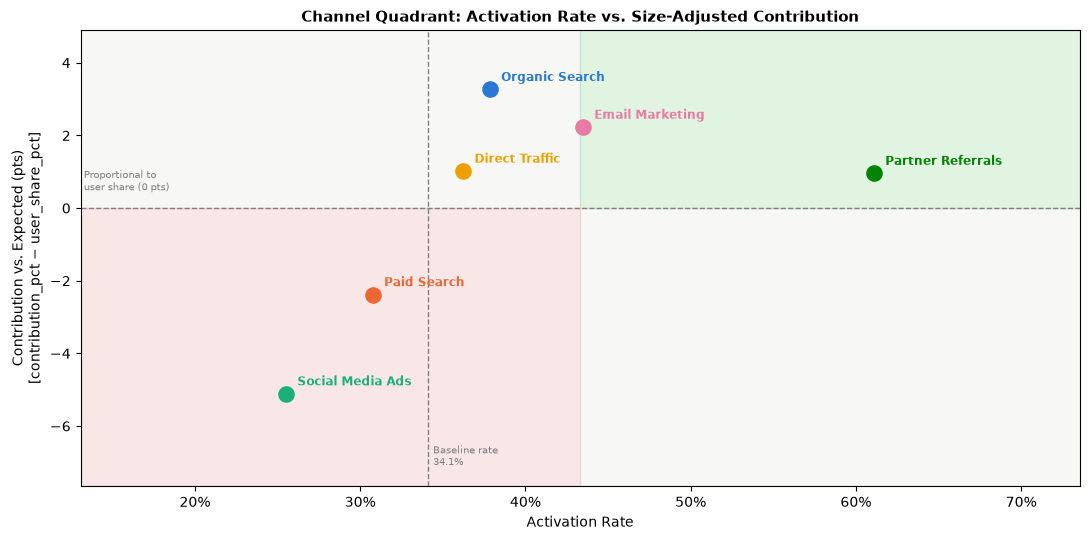

In [72]:
fig, ax = plt.subplots(figsize=(11, 5.5))

# quadrant boundaries — baseline rate on x, contribution_index_pts (actual - expected) on y
x_mid = baseline_activation_rate
y_mid = 0  # 0 = contribution exactly proportional to the channel's share of users

x_pad = (channel_summary["activation_rate"].max() - channel_summary["activation_rate"].min()) * 0.35
x_min, x_max = channel_summary["activation_rate"].min() - x_pad, channel_summary["activation_rate"].max() + x_pad
ax.set_xlim(x_min, x_max)

y_min = channel_summary["contribution_index_pts"].min() * 1.5
y_max = channel_summary["contribution_index_pts"].max() * 1.5

# Quadrant fills are a diverging encoding on two axes (efficiency x contribution), not four
# unrelated categories, so the colors follow that: the "good on both axes" quadrant gets the
# status-good green, "bad on both axes" gets status-critical red, and the two mixed quadrants
# (good on one axis, bad on the other — an ambiguous signal) share one neutral gray rather than
# each getting its own unrelated hue.
color_good = "#0ca30c"      # top-right: above-baseline rate AND over-indexing on contribution
color_bad = "#d03b3b"       # bottom-left: below-baseline rate AND under-indexing on contribution
color_mixed = "#c3c2b7"     # top-left / bottom-right: mixed signal, one axis good, one axis bad

ax.axhspan(y_mid, y_max, xmin=0, xmax=0.5, alpha=0.12, color=color_mixed)   # top-left
ax.axhspan(y_mid, y_max, xmin=0.5, xmax=1, alpha=0.12, color=color_good)    # top-right
ax.axhspan(y_min, y_mid, xmin=0, xmax=0.5, alpha=0.12, color=color_bad)     # bottom-left
ax.axhspan(y_min, y_mid, xmin=0.5, xmax=1, alpha=0.12, color=color_mixed)   # bottom-right

# quadrant lines
ax.axvline(x_mid, color="grey", linestyle="--", linewidth=1)
ax.axhline(y_mid, color="grey", linestyle="--", linewidth=1)

ax.set_ylim(y_min, y_max)

# axis labels for the baseline lines
ax.text(x_mid + 0.003, y_min + 0.5, f"Baseline rate\n{x_mid:.1%}",
        fontsize=7, color="grey", va="bottom")
ax.text(x_min + 0.002, y_mid + 0.4, "Proportional to\nuser share (0 pts)",
        fontsize=7, color="grey", va="bottom")

# plot each channel — repo dataviz categorical palette, fixed slot order (not cycled)
colors = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300"]  # blue, orange, aqua, yellow, magenta, green
for i, row in channel_summary.iterrows():
    ax.scatter(row["activation_rate"], row["contribution_index_pts"], s=120, color=colors[i], zorder=3)
    ax.annotate(
        row["acquisition_channel"],
        xy=(row["activation_rate"], row["contribution_index_pts"]),
        xytext=(8, 6), textcoords="offset points",
        fontsize=8.5, color=colors[i], fontweight="bold"
    )

ax.set_xlabel("Activation Rate", fontsize=10)
ax.set_ylabel("Contribution vs. Expected (pts)\n[contribution_pct − user_share_pct]", fontsize=10)
ax.set_title("Channel Quadrant: Activation Rate vs. Size-Adjusted Contribution", fontsize=11, fontweight="bold")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))

plt.tight_layout()
plt.show()

### Final interpretation

**Headline numbers:** 7,390 users across 6 channels, 2,521 activated, blended baseline activation
rate **34.11%**.

**Quadrant placement** (x = `activation_rate` vs. 34.11% baseline, y = `contribution_index_pts` vs. 0):

| Channel | Users | Activation rate | Index (pts) | Quadrant | Read |
|---|---|---|---|---|---|
| Organic Search | 2,200 | 37.86% | +3.27 | top-right (green) | Largest channel, above-baseline efficiency, over-indexing on contribution. Clear top performer on both dimensions. |
| Direct Traffic | 1,200 | 36.25% | +1.02 | top-right (green) | Above baseline, contribution roughly matches its size, slight over-index. Solid and unremarkable — no red flags. |
| Email Marketing | 600 | 43.50% | +2.23 | top-right (green) | Highest activation rate of any channel at meaningful scale, over-indexing on contribution. Efficient and worth more volume if it can be grown. |
| Partner Referrals | 90 | 61.11% | +0.96 | top-right (green) | Best activation rate in the dataset by a wide margin, but only 90 users — its index is small in *absolute* points purely because the channel is tiny, not because it under-performs. Per the earlier note, it won't scale on its own; treat it as "protect and monitor," not a lever to pull. |
| Paid Search | 1,800 | 30.78% | -2.38 | bottom-left (red) | Second-largest channel, below-baseline efficiency, under-indexing on contribution. A meaningful drag given its size — worth investigating targeting/creative before cutting spend. |
| Social Media Ads | 1,500 | 25.53% | -5.11 | bottom-left (red) | Largest negative index in the dataset — lowest activation rate *and* the biggest gap between its contribution and its user share. The single weakest channel by both axes; highest-priority candidate for root-cause investigation (landing page, audience targeting, funnel drop-off). |

**Correcting an earlier claim in this analysis:** an index near 0 does **not** by itself mean a
channel is under-performing. Algebraically, `contribution_index_pts = user_share_pct × (activation_rate / baseline − 1)`,
so the index is 0 exactly when `activation_rate == baseline` — nothing more. A channel that makes
up a very large share of total users (e.g. ~50%) will itself be close to *defining* the baseline,
so a near-zero index there just confirms it's converting at parity with the blended average, not
that it's "quietly bad." Whether that shared rate is acceptable in absolute terms is a separate,
business-judgment question the index can't answer. In this dataset no single channel is large
enough (max user share is Organic Search at 29.77%) to create that anchoring effect, so quadrant
placement here can be read at face value — but this caveat should be re-checked before reusing the
same index on a channel mix with a dominant (>~40–50% share) channel.

**Limitations:**
- Cross-sectional snapshot only — no time trend, so a channel's current quadrant could be
  improving or declining and this view wouldn't show it.
- No cost/spend data — "over-indexing on contribution" is not the same as "profitable"; Paid
  Search and Social Media Ads carry acquisition costs that free/organic channels don't, so their
  red-quadrant placement understates urgency relative to a channel like Direct Traffic sitting in
  a similar spot.
- No statistical testing — differences in `activation_rate` between channels (e.g. 30.78% vs.
  34.11% for Paid Search) aren't tested for significance; with n=1,800 the gap is likely real, but
  this wasn't formally verified (e.g. via a proportions test).

**Recommended next steps:** (1) root-cause Social Media Ads' low activation rate first, given it's
both the largest deficit and a paid channel; (2) pull in CAC/spend data to re-rank the bottom-left
quadrant by cost-adjusted impact rather than volume alone; (3) revisit this analysis over time
(e.g. monthly) to see whether channels are moving between quadrants rather than relying on a
single static snapshot.


### recommendations 
**Step 4 — quadrant chart.** Plots every channel as one point: x = `activation_rate` (vs. the
`baseline_activation_rate` reference line), y = `contribution_index_pts` (vs. a `0` reference
line). Four quadrants:
- **top-right (green):** above-baseline efficiency *and* over-indexing on volume — the channels to double down on.
- **bottom-right (blue):** efficient, but under-delivering relative to size — room to scale up spend/volume.
- **top-left (orange):** inefficient, but still over-indexing on contribution — usually just a large channel; investigate before cutting.
- **bottom-left (red):** below-baseline efficiency *and* under-indexing — weakest quadrant, first candidates to fix or de-prioritize.

**Caveat:** this is a single-snapshot cross-sectional view (no time dimension, no cohort/spend
data), so it identifies *where* to look, not *why* a channel performs the way it does or whether
performance is trending up or down.
